# 1: Librerie

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

import pickle
import warnings
warnings.filterwarnings('ignore')

# 2: Impostazioni

In [ ]:
random_state = 42
np.random.seed(random_state)
sub_dataset = 0.2
dim = 0.1
pca_perc = 0.95

# 3: Download dataset

In [ ]:
cifar10 = fetch_openml('CIFAR_10', version=1, parser='auto')
X, y = cifar10['data'], cifar10['target']

print(f"- Numero di istanze: {X.shape[0]}")
print(f"- Numero di features: {X.shape[1]}")

X_small, _, y_small, _ = train_test_split(X, y, train_size=sub_dataset, stratify=y, random_state=random_state)

print(f"\n- Numero di istanze nel nuovo dataset: {X_small.shape[0]}")

- Numero di istanze: 60000
- Numero di features: 3072

- Numero di istanze nel nuovo dataset: 12000


# 4: Split dataset

In [ ]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X_small, y_small, test_size= dim, random_state=random_state, stratify=y_small)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size= dim, random_state=random_state, stratify=y_train_val)

print(f"- Numero di istanze nel train set: {X_train.shape[0]}")
print(f"- Numero di istanze nel validation set: {X_val.shape[0]}")
print(f"- Numero di istanze nel test set: {X_test.shape[0]}")

- Numero di istanze nel train set: 9720
- Numero di istanze nel validation set: 1080
- Numero di istanze nel test set: 1200


# 5: Modelli

In [ ]:
modelli = {
    "LogisticRegression": LogisticRegression(max_iter=2000, C=1.0),
    "DecisionTree": DecisionTreeClassifier(max_depth=10),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(C=1.0)
}

# 6: Confronto modelli con PCA e validazione

In [ ]:
risultati = {}
migliori_modelli = {}

for nome, modello in modelli.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components= pca_perc)),
        ('classifier', modello)
    ])

    pipe.fit(X_train, y_train)
    y_val_pred = pipe.predict(X_val)
    acc = accuracy_score(y_val, y_val_pred)
    risultati[nome] = acc
    migliori_modelli[nome] = pipe
    print(f"{nome}: {acc:.4f}")

LogisticRegression: 0.3870
DecisionTree: 0.2417
KNN: 0.2880
SVM: 0.4806


# 7: Selezione del miglior modello e valutazione finale su test

In [ ]:
miglior_nome = max(risultati, key=risultati.get)
miglior_modello = migliori_modelli[miglior_nome]

# Fit finale su train + val
X_final = np.concatenate([X_train, X_val])
y_final = np.concatenate([y_train, y_val])
miglior_modello.fit(X_final, y_final)

# Test finale
y_test_pred = miglior_modello.predict(X_test)
print(f"\nModello scelto: {miglior_nome}")
print("Accuracy test:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))


Modello scelto: SVM
Accuracy test: 0.44583333333333336

Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.47      0.50       120
           1       0.50      0.54      0.52       120
           2       0.30      0.29      0.30       120
           3       0.35      0.33      0.34       120
           4       0.37      0.36      0.36       120
           5       0.39      0.33      0.36       120
           6       0.42      0.50      0.46       120
           7       0.53      0.49      0.51       120
           8       0.56      0.62      0.59       120
           9       0.47      0.53      0.49       120

    accuracy                           0.45      1200
   macro avg       0.44      0.45      0.44      1200
weighted avg       0.44      0.45      0.44      1200



# 8: Confusion matrix

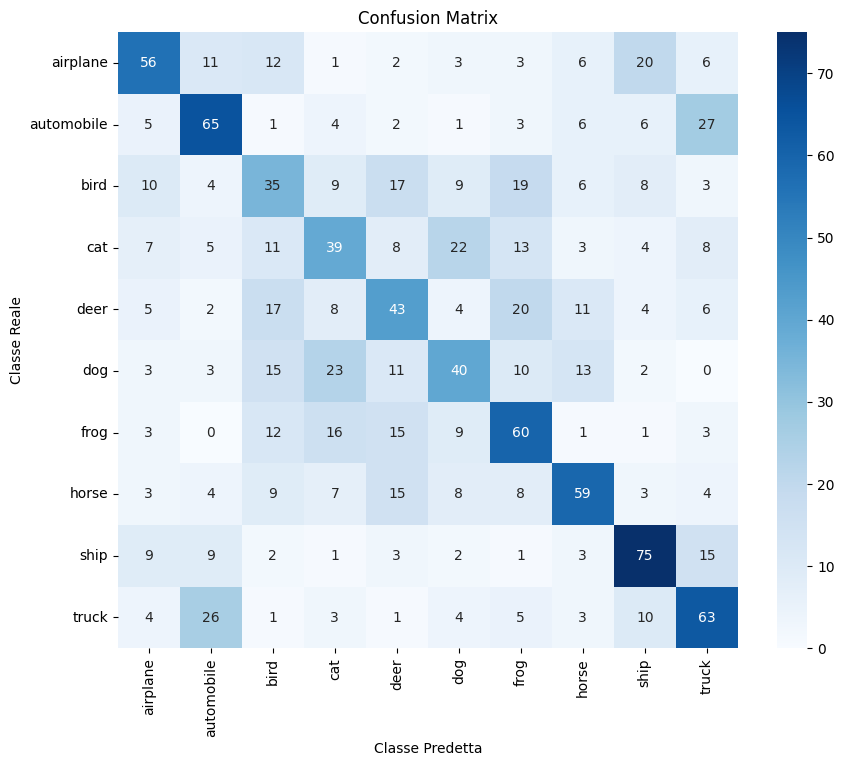

In [ ]:
def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    cifar10_labels = [
        'airplane', 'automobile', 'bird', 'cat', 'deer',
        'dog', 'frog', 'horse', 'ship', 'truck'
    ]
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=cifar10_labels, yticklabels=cifar10_labels)
    plt.xlabel('Classe Predetta')
    plt.ylabel('Classe Reale')
    plt.title('Confusion Matrix')
    plt.show()

plot_confusion_matrix(y_test, y_test_pred)
